## Imports

In [1]:
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [2]:
sns.set_theme(style="ticks", context="notebook")

## Load .dil file

In [3]:
file_name = "Study1.dil"

g = globals()
with open(file_name, "rb") as file:
    list_of_variable_names = dill.load(file)
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)

print("variables that have been loaded:")
print(list_of_variable_names)

variables that have been loaded:
('lps', 'posterior_samples_mu_a', 'posterior_samples_sigma_a', 'posterior_samples_mu_sigmasq', 'posterior_samples_beta_sigmasq', 'posterior_samples_mu_w', 'posterior_samples_sigma_w', 'posterior_samples_sigma_mu_x', 'posterior_samples_mu_x', 'posterior_samples_a', 'posterior_samples_sigmasq', 'posterior_samples_w', 'posterior_samples_states', 'num_trials', 'num_inputs', 'num_trials_per_subject', 'num_subjects', 'num_iters', 'inputs', 'emissions', 'masks')


In [5]:
per = pd.read_csv("../../../Data/PerceptualTaskData.csv")
per["IDcode"] = pd.to_numeric(per["IDcode"], errors="coerce").astype("Int64")

sym = pd.read_csv("../../../Data/SymptomData.csv")
sym["IDcode"] = pd.to_numeric(sym["IDcode"], errors="coerce")

print(sym.columns.tolist())
sym.head()

print("posterior_samples_a shape:", posterior_samples_a.shape)
print("posterior_samples_sigmasq shape:", posterior_samples_sigmasq.shape)
print(per.shape)
print(per.columns.tolist())

['IDcode', 'Age', 'Sex', 'AnxiousDepression', 'Compulsivity', 'SocialWithdrawal']
posterior_samples_a shape: (4, 2000, 344)
posterior_samples_sigmasq shape: (4, 2000, 344)
(155088, 7)
['IDcode', 'Age', 'Sex', 'Trial', 'Response', 'Stimulus', 'Confidence']


In [6]:
keep_ids_list = [
    1109430,1136398,1161576,990377,988880,989613,989614,989638,990171,990502,
    1019534,1019545,1019829,1020003,1020094,1026298,1031230,1056155,1076128,
    1076202,1076245,1076467,1077091,1077672,1077748,1083215,1085767,1086215,
    1086429,1086524,1086722,1087676,1087803,1089279,1089330,1089829,1092255,
    1092315,1096800,1097476,1098724,1098967,1099520,1101067,1107685,1107856,
    1109466,1111115,1112029,1112249,1113314,1114743,1114859,944548,953958,
    954010,954564,957126,957158,958563,958619,959561,961534,965512,966909,
    967485,967866,969340,972471,974295,980324,984514,985216,988163,991011,
    998453,1029483,1029603,1029776,1029858,1030062,1030377,1030394,1030711,
    1031236,1032579,1060694,1071048,1072306,954995,955009,955021,955023,
    955077,955083,955102,955119,955240,955276,955303,955342,955383,955683,
    955984,956021,956352,956553,956843,956927,956993,957089,957167,957953,
    958100,958257,958360,958541,958577,958771,959130,959386,959708,960758,
    960817,961191,961560,961864,963283,964156,966004,966051,967144,967215,
    968578,968792,969242,969364,970091,970214,971440,971577,972235,972410,
    972412,972585,972608,972740,973276,973356,973496,973708,973896,974187,
    975356,977249,977374,978290,979523,979791,981984,982296,982316,982404,
    984377,990840,992115,992526,1000003,1002300,1003011,1005185,1055457,
    1055828,1056146,1056537,1057764,1057805,1058277,1058510,1058926,1059194,
    1059249,1059261,1059408,1059911,1060742,1063610,1067860,1069381,1069895,
    1069986,1071196,1071224,1071343,1072006,1072034,1072153,1072208,1074018,
    1074043,1074460,1076254,1077140,1077499,1077520,1077746,1079257,1080555,
    1080861,1081810,1083775,1084292,1084496,1085727,1086436,1087954,1088055,
    1089319,1089331,1089431,1089461,1094362,1094757,1099082,1099754,1100590,
    1102002,1105080,1105574,1106651,1107155,1113140,1113399,1117048,1123812,
    1139756,1164558,982442,982693,983044,983545,983866,983911,984204,984214,
    984218,984230,984337,984798,985205,985936,987475,1005286,1025813,1025854,
    1027427,1028174,1033318,1033745,1039326,1040390,1060306,1066153,1080350,
    1094893,970018,971334,971779,972231,972352,972382,972433,972550,973225,
    973843,974106,974217,974241,974337,974406,974604,974795,975381,975696,
    976140,976152,976614,976932,984212,985153,989292,992393,1000944,1003223,
    1003328,1008892,1008967,1009029,1052583,1059466,1060303,1060654,1061755,
    1066043,1066212,1066462,1066559,1066606,1066734,1068331,1068985,966047,
    969684,969744,969855,970770,973065,973458,1026348,1030251,1030362,1030403,
    1030520,1030648,1031514,1031608,1031873,1032457,1032513,1032530,1032639,
    1033030,1033395,1033397,1033887,1039513,1039632,1039920,1040014,1041483,
    1047104,1054199,1056861,1069540
]

keep_ids_set = set(keep_ids_list)

In [7]:
per = per[per["IDcode"].isin(keep_ids_set)].copy()

data = per.rename(columns={
    "IDcode": "subj",
    "Response": "resp",
    "Stimulus": "evidence",
    "Trial": "trial"
}).copy()

data = data[data["evidence"] != 0].copy()
data["resp"] = data["resp"].astype(int)
data = data.sort_values(["subj", "trial"]).copy()

subj_ids_sorted = np.sort(data["subj"].unique()).astype(int)

available_ids = set(data["subj"].unique())
subj_ids_keep_order = np.array(
    [x for x in keep_ids_list if x in available_ids],
    dtype=int
)

print("n sorted:", len(subj_ids_sorted))
print("n keep-order:", len(subj_ids_keep_order))
print("posterior subjects:", posterior_samples_a.shape[-1])
print("num_subjects:", num_subjects)

print("Same set:", set(subj_ids_sorted) == set(subj_ids_keep_order))
print("Same order:", np.array_equal(subj_ids_sorted, subj_ids_keep_order))

subj_ids = subj_ids_sorted

n sorted: 344
n keep-order: 344
posterior subjects: 344
num_subjects: 344
Same set: True
Same order: False


In [8]:
burn_in = 1000

post_a = posterior_samples_a[:, burn_in:, :]
post_a = np.array(post_a).reshape(-1, posterior_samples_a.shape[-1])
a_mean = np.mean(post_a, axis=0)

post_sigmasq = posterior_samples_sigmasq[:, burn_in:, :]
post_sigmasq = np.array(post_sigmasq).reshape(-1, posterior_samples_sigmasq.shape[-1])
sigmasq_mean = np.mean(post_sigmasq, axis=0)

# criterion trajectories (latent states)
post_states = posterior_samples_states[:, burn_in:, :, :]  
post_states = np.array(post_states)

# posterior mean criterion per subject x trial
criterion_mean = post_states.mean(axis=(0, 1))   

# participant-level fluctuation metrics
mean_criterion = criterion_mean.mean(axis=1)
sd_criterion = criterion_mean.std(axis=1, ddof=1)

mad_criterion = np.mean(
    np.abs(criterion_mean - mean_criterion[:, None]),
    axis=1
)

mean_abs_diff_criterion = np.mean(
    np.abs(np.diff(criterion_mean, axis=1)),
    axis=1
)

hmfc_df = pd.DataFrame({
    "IDcode": subj_ids.astype(int),
    "a": a_mean,
    "sigmasq": sigmasq_mean,
    "mean_criterion": mean_criterion,
    "sd_criterion": sd_criterion,
    "mad_criterion": mad_criterion,
    "mean_abs_diff_criterion": mean_abs_diff_criterion
})
hmfc_df.to_csv("hmfc_results.csv", index=False)

hmfc_df.head()

,IDcode,a,sigmasq,mean_criterion,sd_criterion,mad_criterion,mean_abs_diff_criterion
0,944548,0.826401,0.079071,-0.001270,0.155237,0.117240,0.025504
1,953958,0.907681,0.128221,0.101184,0.598658,0.457767,0.049884
2,954010,0.863703,0.115718,-0.122189,0.378393,0.261725,0.043172
3,954564,0.907068,0.113038,-0.001395,0.525766,0.434916,0.041039
4,954995,0.922701,0.109287,-0.757276,0.650583,0.540555,0.044342


In [9]:
sym_participant = (
    sym.groupby("IDcode", as_index=False)[
        ["Age", "Sex", "AnxiousDepression", "Compulsivity", "SocialWithdrawal"]
    ]
    .first()
)

print(sym_participant.shape)
print(sym_participant.head())
print("Unique IDs in symptom data:", sym_participant["IDcode"].nunique())

(1098, 6)
   IDcode  Age  Sex  AnxiousDepression  Compulsivity  SocialWithdrawal
0  944548   21    0          -0.293255     -0.621615         -0.032964
1  953958   21    0          -0.566733     -0.123265          0.518405
2  954010   22    0           1.802008      1.126410         -0.098002
3  954564   20    0          -0.528183      0.330763         -0.704537
4  954995   21    0          -0.724605     -0.504122          0.172939
Unique IDs in symptom data: 1098


## Merge symptomdata with hMFC results

In [10]:
df = hmfc_df.merge(sym_participant, on="IDcode", how="inner")
df.to_csv("hmfc_with_symptoms.csv", index=False)

print("Merged dataframe shape:", df.shape)
print("Unique participants in merged df:", df["IDcode"].nunique())
df.head()

Merged dataframe shape: (344, 12)
Unique participants in merged df: 344


,IDcode,a,sigmasq,mean_criterion,sd_criterion,mad_criterion,mean_abs_diff_criterion,Age,Sex,AnxiousDepression,Compulsivity,SocialWithdrawal
0,944548,0.826401,0.079071,-0.001270,0.155237,0.117240,0.025504,21,0,-0.293255,-0.621615,-0.032964
1,953958,0.907681,0.128221,0.101184,0.598658,0.457767,0.049884,21,0,-0.566733,-0.123265,0.518405
2,954010,0.863703,0.115718,-0.122189,0.378393,0.261725,0.043172,22,0,1.802008,1.126410,-0.098002
3,954564,0.907068,0.113038,-0.001395,0.525766,0.434916,0.041039,20,0,-0.528183,0.330763,-0.704537
4,954995,0.922701,0.109287,-0.757276,0.650583,0.540555,0.044342,21,0,-0.724605,-0.504122,0.172939


## log-transform sigmasq (probably better for regression)

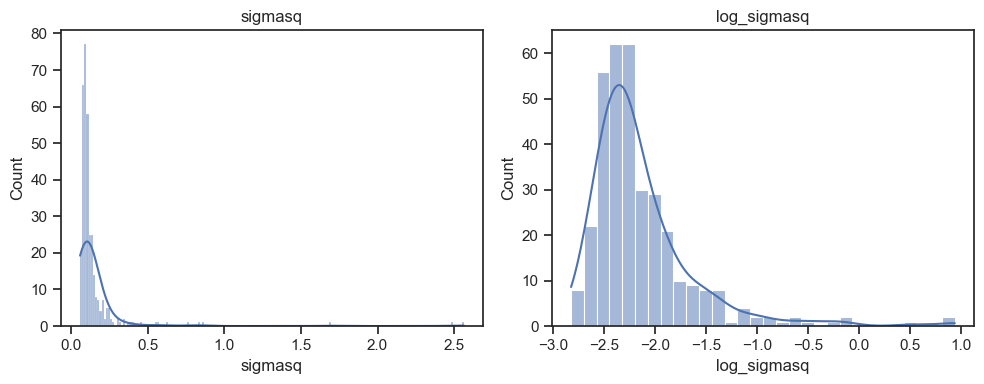

In [11]:
df = df[df["sigmasq"] < 12].copy()
df["log_sigmasq"] = np.log(df["sigmasq"])
df["log_mad_criterion"] = np.log(df["mad_criterion"])
df["log_sd_criterion"] = np.log(df["sd_criterion"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df["sigmasq"], kde=True, ax=axes[0])
axes[0].set_title("sigmasq")

sns.histplot(df["log_sigmasq"], kde=True, ax=axes[1])
axes[1].set_title("log_sigmasq")

plt.tight_layout()
plt.show()

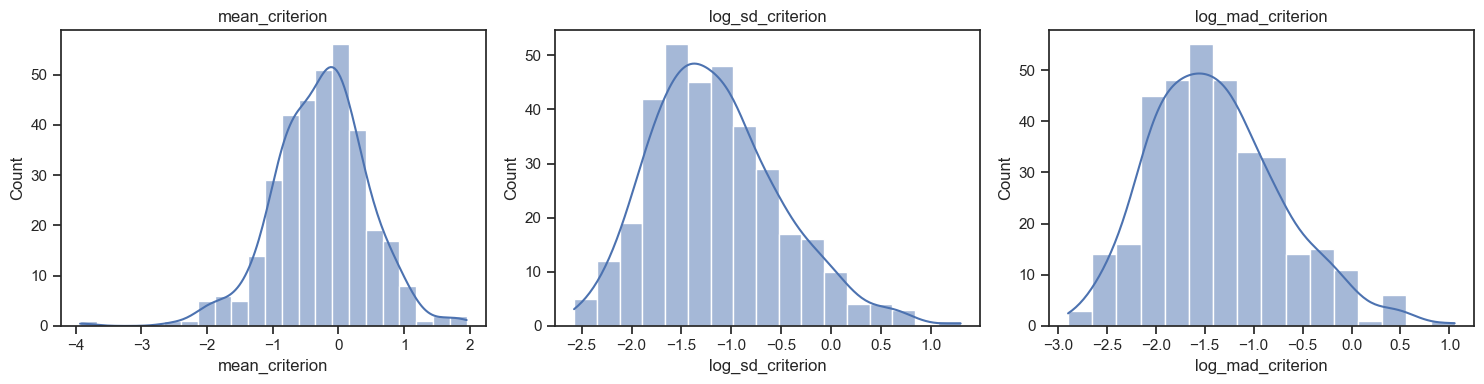

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["mean_criterion"], kde=True, ax=axes[0])
axes[0].set_title("mean_criterion")

sns.histplot(df["log_sd_criterion"], kde=True, ax=axes[1])
axes[1].set_title("log_sd_criterion")

sns.histplot(df["log_mad_criterion"], kde=True, ax=axes[2])
axes[2].set_title("log_mad_criterion")

plt.tight_layout()
plt.show()

## Naive tertile approach

In [13]:
df_tert = df.copy()

df_tert["AD_tertile"] = pd.qcut(df_tert["AnxiousDepression"], 3, labels=["low","mid","high"])
df_tert["CIT_tertile"] = pd.qcut(df_tert["Compulsivity"], 3, labels=["low","mid","high"])
df_tert["SW_tertile"] = pd.qcut(df_tert["SocialWithdrawal"], 3, labels=["low","mid","high"])

In [14]:
summary = df_tert.groupby("CIT_tertile")[["a","sigmasq"]].agg(["mean","sem"])
summary

/var/folders/4y/sm89msfj70b1mnhdgv9yqnfr0000gn/T/ipykernel_24169/876869678.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_tert.groupby("CIT_tertile")[["a","sigmasq"]].agg(["mean","sem"])


a             sigmasq          
                 mean       sem      mean       sem
CIT_tertile                                        
low          0.869018  0.003038  0.127444  0.008488
mid          0.867536  0.003457  0.171842  0.026702
high         0.862082  0.003346  0.147514  0.022726

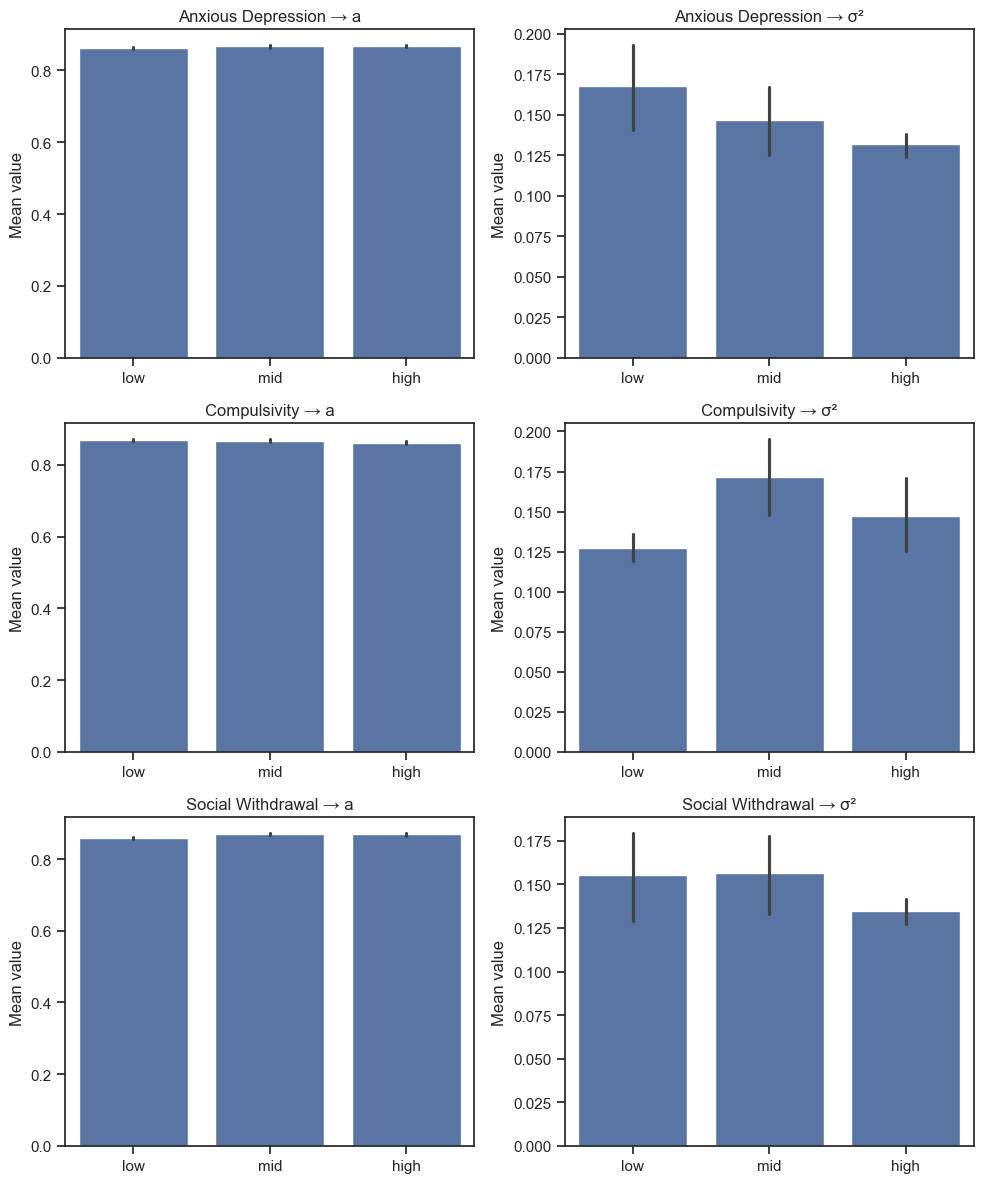

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

dimensions = [
    ("AD_tertile", "Anxious Depression"),
    ("CIT_tertile", "Compulsivity"),
    ("SW_tertile", "Social Withdrawal")
]

for i, (tert, label) in enumerate(dimensions):

    sns.barplot(
        data=df_tert,
        x=tert,
        y="a",
        order=["low", "mid", "high"],
        errorbar=("ci", 68),
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{label} → a")
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Mean value")

    sns.barplot(
        data=df_tert,
        x=tert,
        y="sigmasq",
        order=["low", "mid", "high"],
        errorbar=("ci", 68),
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{label} → σ²")
    axes[i, 1].set_xlabel("")
    axes[i, 1].set_ylabel("Mean value")

plt.tight_layout()
plt.show()

## Regression

In [16]:
df_reg = df.copy()

z_cols = ["Age", "AnxiousDepression", "Compulsivity", "SocialWithdrawal"]
scaler = StandardScaler()
df_reg[[c + "_z" for c in z_cols]] = scaler.fit_transform(df_reg[z_cols])

df_reg.head()

,IDcode,a,sigmasq,mean_criterion,sd_criterion,mad_criterion,mean_abs_diff_criterion,Age,Sex,AnxiousDepression,Compulsivity,SocialWithdrawal,log_sigmasq,log_mad_criterion,log_sd_criterion,Age_z,AnxiousDepression_z,Compulsivity_z,SocialWithdrawal_z
0,944548,0.826401,0.079071,-0.001270,0.155237,0.117240,0.025504,21,0,-0.293255,-0.621615,-0.032964,-2.537414,-2.143532,-1.862802,-0.414546,-0.307005,-0.764087,0.045106
1,953958,0.907681,0.128221,0.101184,0.598658,0.457767,0.049884,21,0,-0.566733,-0.123265,0.518405,-2.054003,-0.781396,-0.513064,-0.414546,-0.601974,-0.222807,0.642997
2,954010,0.863703,0.115718,-0.122189,0.378393,0.261725,0.043172,22,0,1.802008,1.126410,-0.098002,-2.156596,-1.340461,-0.971823,-0.319223,1.952904,1.134520,-0.025419
3,954564,0.907068,0.113038,-0.001395,0.525766,0.434916,0.041039,20,0,-0.528183,0.330763,-0.704537,-2.180034,-0.832603,-0.642898,-0.509869,-0.560394,0.270332,-0.683130
4,954995,0.922701,0.109287,-0.757276,0.650583,0.540555,0.044342,21,0,-0.724605,-0.504122,0.172939,-2.213779,-0.615159,-0.429887,-0.414546,-0.772251,-0.636473,0.268382


In [17]:
df_reg["sex_num"] = pd.to_numeric(df_reg["Sex"], errors="coerce")

In [18]:
def run_regression(df, outcome, predictors, add_age=True, add_sex=True):
    X_cols = predictors.copy()

    if add_age:
        X_cols.append("Age_z")
    if add_sex:
        X_cols.append("sex_num")

    tmp = df[[outcome] + X_cols].dropna().copy()

    X = sm.add_constant(tmp[X_cols])
    y = tmp[outcome]

    model = sm.OLS(y, X).fit()

    print("\n" + "="*60)
    print(f"Outcome: {outcome}")
    print(f"Predictors: {X_cols}")
    print("="*60)
    print(model.summary())

    return model

In [19]:
predictors_all = ["AnxiousDepression_z", "Compulsivity_z", "SocialWithdrawal_z"]

single_models = {}

for pred in predictors_all:
    m_a = run_regression(
        df_reg,
        outcome="a",
        predictors=[pred],
        add_age=True,
        add_sex=True
    )

    m_s = run_regression(
        df_reg,
        outcome="sigmasq",
        predictors=[pred],
        add_age=True,
        add_sex=True
    )

    m_mad = run_regression(
        df_reg,
        outcome="log_mad_criterion",
        predictors=[pred],
        add_age=True,
        add_sex=True
    )

    m_sd = run_regression(
        df_reg,
        outcome="log_sd_criterion",
        predictors=[pred],
        add_age=True,
        add_sex=True
    )

    single_models[(pred, "a")] = m_a
    single_models[(pred, "sigmasq")] = m_s
    single_models[(pred, "log_mad_criterion")] = m_mad
    single_models[(pred, "log_sd_criterion")] = m_sd


Outcome: a
Predictors: ['AnxiousDepression_z', 'Age_z', 'sex_num']
                            OLS Regression Results                            
Dep. Variable:                      a   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.4667
Date:                Wed, 24 Jun 2026   Prob (F-statistic):              0.706
Time:                        12:05:18   Log-Likelihood:                 664.42
No. Observations:                 344   AIC:                            -1321.
Df Residuals:                     340   BIC:                            -1305.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [20]:
def extract_single_model_results(single_models):
    rows = []

    predictor_label_map = {
        "AnxiousDepression_z": "AD",
        "Compulsivity_z": "CIT",
        "SocialWithdrawal_z": "SW"
    }

    outcome_label_map = {
        "a": "a",
        "sigmasq": "σ²",
        "log_mad_criterion": "log(MAD criterion)",
        "log_sd_criterion": "log(SD criterion)"
    }

    for (pred, outcome), model in single_models.items():
        conf = model.conf_int()

        rows.append({
            "predictor": predictor_label_map[pred],
            "outcome": outcome_label_map[outcome],
            "beta": model.params[pred],
            "ci_low": conf.loc[pred, 0],
            "ci_high": conf.loc[pred, 1],
            "p": model.pvalues[pred]
        })

    return pd.DataFrame(rows)

single_plot_df = extract_single_model_results(single_models)
single_plot_df

,predictor,outcome,beta,ci_low,ci_high,p
0,AD,a,0.001958,-0.001901,0.005817,0.318947
1,AD,σ²,-0.012446,-0.036870,0.011978,0.316889
2,AD,log(MAD criterion),0.020769,-0.052805,0.094343,0.579084
3,AD,log(SD criterion),0.015752,-0.055421,0.086925,0.663604
4,CIT,a,-0.002439,-0.006407,0.001530,0.227638
5,CIT,σ²,0.010361,-0.014787,0.035509,0.418292
6,CIT,log(MAD criterion),-0.021326,-0.097044,0.054392,0.579942
7,CIT,log(SD criterion),-0.024429,-0.097650,0.048792,0.512109
8,SW,a,0.002990,-0.000883,0.006863,0.129828
9,SW,σ²,-0.012611,-0.037171,0.011950,0.313238


In [21]:
def plot_single_models(single_plot_df, title="Single-predictor regression models"):
    predictors = ["AD", "CIT", "SW"]
    outcomes =  ["a", "σ²", "log(SD criterion)", "log(MAD criterion)"]

    x = np.arange(len(predictors))
    width = 0.18
    offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

    fig, ax = plt.subplots(figsize=(9, 5))

    for i, outcome in enumerate(outcomes):
        sub = single_plot_df[single_plot_df["outcome"] == outcome].copy()
        sub = sub.set_index("predictor").loc[predictors].reset_index()

        betas = sub["beta"].values
        ci_low = sub["ci_low"].values
        ci_high = sub["ci_high"].values

        yerr = np.vstack([
            betas - ci_low,
            ci_high - betas
        ])

        ax.bar(
            x + offsets[i],
            betas,
            width=width,
            yerr=yerr,
            capsize=4,
            label=outcome
        )

        for j, row in sub.iterrows():
            if row["p"] < 0.05:
                star_y = min(row["ci_low"] - 0.03, -0.03)
                ax.text(
                    x[j] + offsets[i],
                    star_y,
                    "*",
                    ha="center",
                    va="top",
                    fontsize=16
                )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(predictors)
    ax.set_ylabel("Regression coefficient")
    ax.set_xlabel("Predictor")
    ax.set_title(title)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

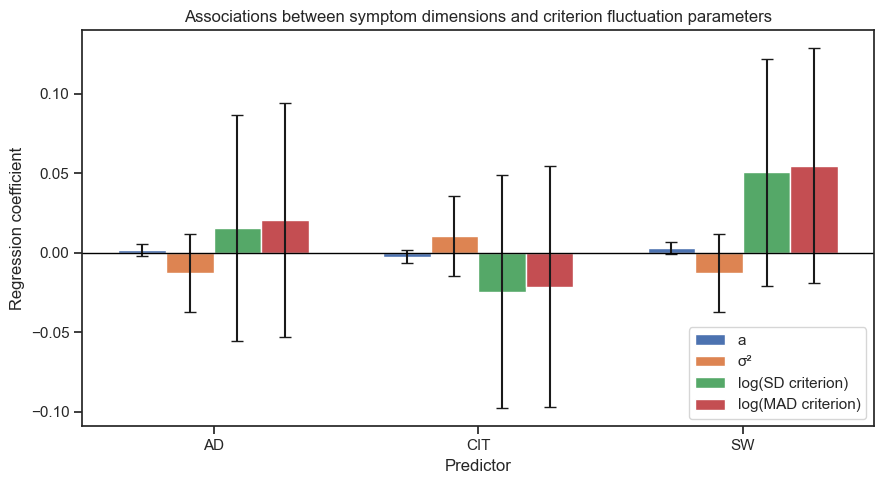

In [22]:
plot_single_models(
    single_plot_df,
    title="Associations between symptom dimensions and criterion fluctuation parameters"
)

## Combined regression

In [23]:
predictors_all = ["AnxiousDepression_z", "Compulsivity_z", "SocialWithdrawal_z"]

model_a_combined = run_regression(
    df_reg,
    outcome="a",
    predictors=predictors_all,
    add_age=True,
    add_sex=True
)

model_s_combined = run_regression(
    df_reg,
    outcome="sigmasq",
    predictors=predictors_all,
    add_age=True,
    add_sex=True
)

model_mad_combined = run_regression(
    df_reg,
    outcome="log_mad_criterion",
    predictors=predictors_all,
    add_age=True,
    add_sex=True
)

model_sd_combined = run_regression(
    df_reg,
    outcome="log_sd_criterion",
    predictors=predictors_all,
    add_age=True,
    add_sex=True
)


Outcome: a
Predictors: ['AnxiousDepression_z', 'Compulsivity_z', 'SocialWithdrawal_z', 'Age_z', 'sex_num']
                            OLS Regression Results                            
Dep. Variable:                      a   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.341
Date:                Wed, 24 Jun 2026   Prob (F-statistic):              0.247
Time:                        12:05:32   Log-Likelihood:                 667.09
No. Observations:                 344   AIC:                            -1322.
Df Residuals:                     338   BIC:                            -1299.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------

In [24]:
def extract_combined_results(model, outcome):
    
    rows = []
    conf = model.conf_int()
    
    predictors = {
        "AnxiousDepression_z": "AD",
        "Compulsivity_z": "CIT",
        "SocialWithdrawal_z": "SW"
    }
    
    for pred, label in predictors.items():
        
        rows.append({
            "predictor": label,
            "outcome": outcome,
            "beta": model.params[pred],
            "ci_low": conf.loc[pred,0],
            "ci_high": conf.loc[pred,1],
            "p": model.pvalues[pred]
        })
    
    return pd.DataFrame(rows)

In [25]:
combined_plot_df = pd.concat([
    
    extract_combined_results(model_a_combined, "a"),
    extract_combined_results(model_s_combined, "σ²"),
    extract_combined_results(model_mad_combined, "log(MAD criterion)"),
    extract_combined_results(model_sd_combined, "log(SD criterion)")
])
    
combined_plot_df

,predictor,outcome,beta,ci_low,ci_high,p
0,AD,a,0.002078,-0.002493,0.006649,0.371900
1,CIT,a,-0.004366,-0.008730,-0.000003,0.049845
2,SW,a,0.003340,-0.001100,0.007779,0.139861
0,AD,σ²,-0.014727,-0.043783,0.014329,0.319490
1,CIT,σ²,0.020205,-0.007529,0.047939,0.152770
2,SW,σ²,-0.011793,-0.040010,0.016424,0.411593
0,AD,log(MAD criterion),0.007766,-0.079690,0.095222,0.861447
1,CIT,log(MAD criterion),-0.045404,-0.128881,0.038072,0.285431
2,SW,log(MAD criterion),0.064959,-0.019971,0.149889,0.133393
0,AD,log(SD criterion),0.004118,-0.080471,0.088708,0.923761


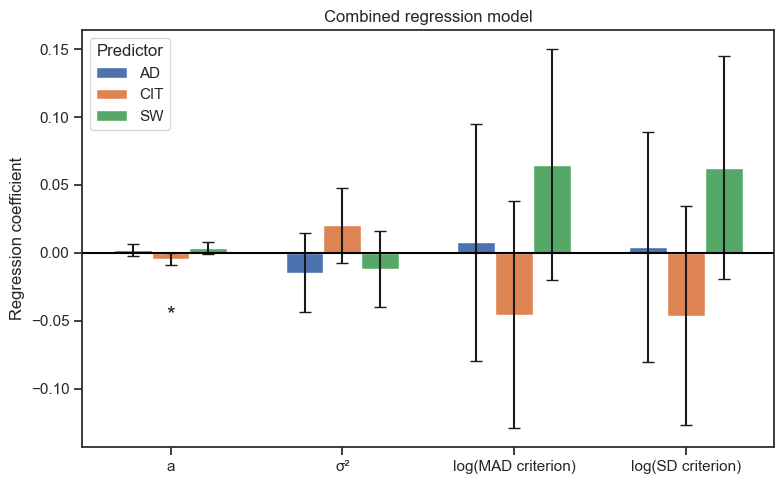

In [26]:
predictors = ["AD","CIT","SW"]
outcomes = ["a","σ²", "log(MAD criterion)", "log(SD criterion)"]

x = np.arange(len(outcomes))
width = 0.22
offsets = [-width,0,width]

fig, ax = plt.subplots(figsize=(8,5))

for i,pred in enumerate(predictors):
    
    sub = combined_plot_df[combined_plot_df["predictor"]==pred]
    sub = sub.set_index("outcome").loc[outcomes].reset_index()
    
    betas = sub["beta"].values
    ci_low = sub["ci_low"].values
    ci_high = sub["ci_high"].values
    
    yerr = np.vstack([betas-ci_low,ci_high-betas])
    
    ax.bar(
        x+offsets[i],
        betas,
        width=width,
        yerr=yerr,
        capsize=4,
        label=pred
    )
    
    for j,row in sub.iterrows():
        
        if row["p"] < 0.05:
            
            ax.text(
                x[j]+offsets[i],
                row["ci_low"]-0.03,
                "*",
                ha="center",
                va="top",
                fontsize=16
            )

ax.axhline(0,color="black")

ax.set_xticks(x)
ax.set_xticklabels(outcomes)

ax.set_ylabel("Regression coefficient")
ax.set_title("Combined regression model")

ax.legend(title="Predictor")

plt.tight_layout()
plt.show()

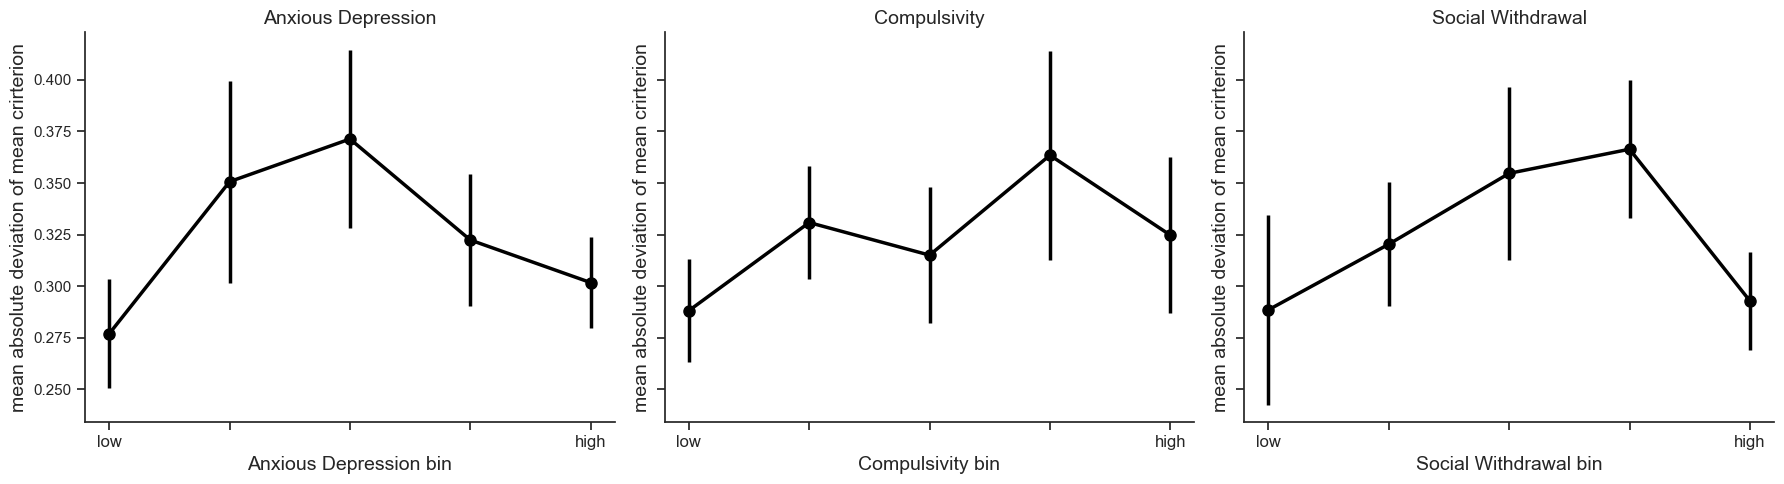

In [27]:
#AI was used to help with lay out

def make_dimension_bin_plot(
    df,
    dim_col,
    y_col="mad_criterion",
    n_bins=5,
    ax=None,
    title=None,
    y_label="abs. deviation from mean criterion"
):
    """
    - x-axis: symptom scores divided into quantile bins (low → high)
    - y-axis: mean of the outcome variable (e.g., MAD of criterion)
    """
    
    # Select relevant columns and drop missing values
    tmp = df[[dim_col, y_col]].dropna().copy()

    # Create quantile-based bins (e.g., 5 bins from low to high)
    tmp["bin"] = pd.qcut(
        tmp[dim_col],
        q=n_bins,
        labels=False,
        duplicates="drop"  # handle tied values
    )

    # Determine the actual number of bins (in case of duplicates)
    actual_bins = tmp["bin"].nunique()

    # Compute summary statistics per bin
    summary = (
        tmp.groupby("bin", as_index=False)
        .agg(
            mean_y=(y_col, "mean"),   # mean of outcome
            sem_y=(y_col, "sem"),     # standard error
            mean_dim=(dim_col, "mean"),  # average symptom score per bin
            n=(y_col, "size")         # number of observations
        )
        .sort_values("bin")
        .reset_index(drop=True)
    )

    # X-axis positions (0,1,2,...)
    x = np.arange(actual_bins)

    # Create axis if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    # Plot line with error bars
    ax.errorbar(
        x,
        summary["mean_y"],
        yerr=summary["sem_y"],
        fmt="o-",
        color="black",
        linewidth=2.5,
        markersize=8,
        capsize=0
    )

    # Only label first and last bin as "low" and "high"
    xticklabels = [""] * actual_bins
    xticklabels[0] = "low"
    xticklabels[-1] = "high"

    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, fontsize=12)

    # Axis labels
    ax.set_xlabel(f"{title if title is not None else dim_col} bin", fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)

    # Optional subplot title
    if title is not None:
        ax.set_title(title, fontsize=14)

    # Remove top/right spines for cleaner look
    sns.despine(ax=ax)

    return summary


# Select outcome variable
yvar = "mad_criterion"
ylab = "mean absolute deviation of mean crirterion"

# Create subplots for the three symptom dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Anxious Depression
summary_AD = make_dimension_bin_plot(
    df,
    dim_col="AnxiousDepression",
    y_col=yvar,
    n_bins=5,
    ax=axes[0],
    title="Anxious Depression",
    y_label=ylab
)

# Compulsivity
summary_CIT = make_dimension_bin_plot(
    df,
    dim_col="Compulsivity",
    y_col=yvar,
    n_bins=5,
    ax=axes[1],
    title="Compulsivity",
    y_label=ylab
)

# Social Withdrawal
summary_SW = make_dimension_bin_plot(
    df,
    dim_col="SocialWithdrawal",
    y_col=yvar,
    n_bins=5,
    ax=axes[2],
    title="Social Withdrawal",
    y_label=ylab
)

plt.tight_layout()
plt.show()

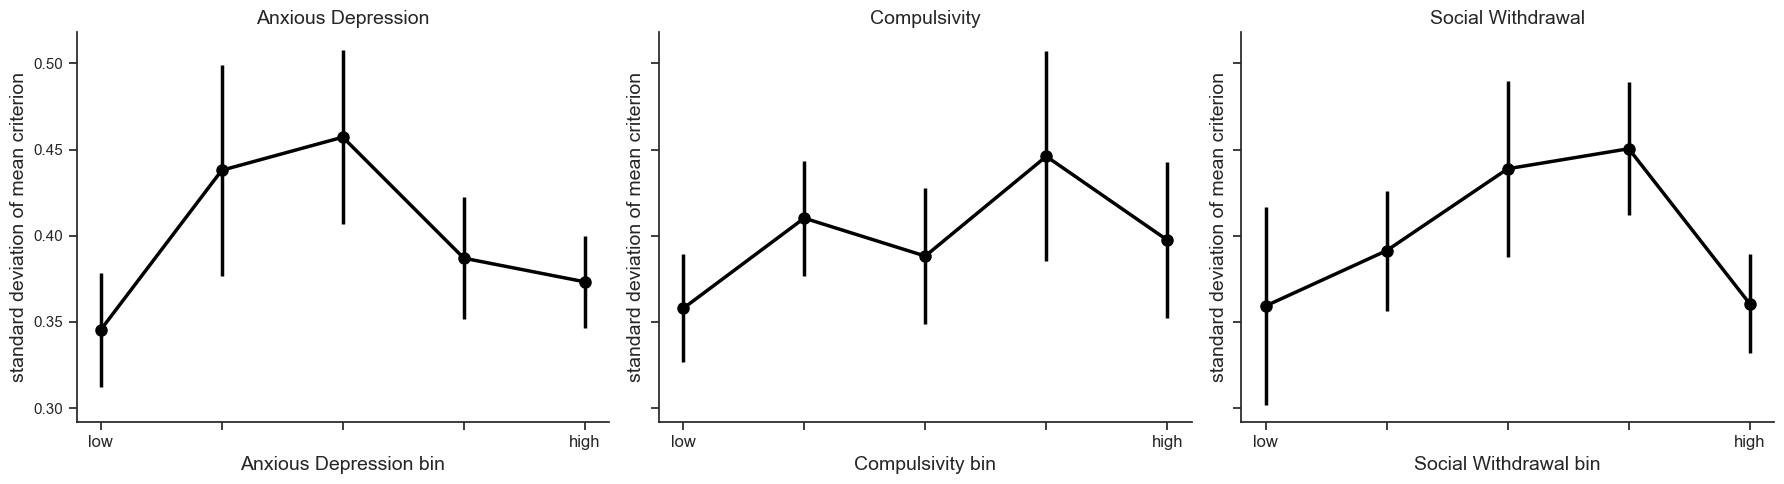

In [28]:
# Select outcome variable
yvar = "sd_criterion"
ylab = "standard deviation of mean criterion"

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Anxious Depression
summary_AD = make_dimension_bin_plot(
    df,
    dim_col="AnxiousDepression",
    y_col=yvar,
    n_bins=5,
    ax=axes[0],
    title="Anxious Depression",
    y_label=ylab
)

# Compulsivity
summary_CIT = make_dimension_bin_plot(
    df,
    dim_col="Compulsivity",
    y_col=yvar,
    n_bins=5,
    ax=axes[1],
    title="Compulsivity",
    y_label=ylab
)

# Social Withdrawal
summary_SW = make_dimension_bin_plot(
    df,
    dim_col="SocialWithdrawal",
    y_col=yvar,
    n_bins=5,
    ax=axes[2],
    title="Social Withdrawal",
    y_label=ylab
)

plt.tight_layout()
plt.show()